In [ ]:
%pip install -q numpy pandas matplotlib scikit-learn joblib catboost pyarrow

import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from catboost import CatBoostClassifier

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# ============================================================
# 전처리 완료된 parquet 파일 로드 (로컬 환경용)
# ============================================================

import os
import pandas as pd

TRAIN_PATH = os.path.join('processed_5m', 'train_tabular_ML_opt.parquet')
TEST_PATH = os.path.join('processed_5m', 'test_tabular_ML_opt.parquet')

for path in [TRAIN_PATH, TEST_PATH]:
    if not os.path.exists(path):
        available = [f for f in os.listdir('processed_5m') if f.endswith('.parquet')]
        raise FileNotFoundError(
            f"'{path}' 파일을 찾을 수 없습니다. processed_5m 폴더의 parquet 파일: {available}"
        )

train_df = pd.read_parquet(TRAIN_PATH)
test_df = pd.read_parquet(TEST_PATH)

print('Train 크기:', train_df.shape)
print('Test 크기:', test_df.shape)

print('\n컬럼 목록:')
print(train_df.columns.tolist())

print('\nTrain 데이터 확인:')
display(train_df.head())

print('\nTest 데이터 확인:')
display(test_df.head())

Train 크기: (109378, 12)
Test 크기: (109736, 12)

컬럼 목록:
['recency_days', 'tenure_days', 'ndays', 'n_events', 'n_view', 'n_cart', 'n_remove_from_cart', 'n_purchase', 'avg_price', 'purch_amt', 'churn', 'user_id']

Train 데이터 확인:


,recency_days,tenure_days,ndays,n_events,n_view,n_cart,n_remove_from_cart,n_purchase,avg_price,purch_amt,churn,user_id
0,0.744742,0.000000,0.000000,0.000000,0.070130,0.000000,0.000000,0.000000,0.021783,0.000000,1,9582366
1,0.539424,0.066815,0.230787,0.335133,0.340690,0.322270,0.214858,0.000000,0.019697,0.000000,0,12961898
2,0.208004,0.000036,0.000000,0.238987,0.297907,0.000000,0.000000,0.000000,0.024063,0.000000,1,16460232
3,0.326894,0.000007,0.000000,0.043042,0.000000,0.134158,0.000000,0.000000,0.015300,0.000000,1,17130461
4,0.324472,0.967386,0.592242,0.602799,0.605432,0.532022,0.558078,0.343591,0.016679,0.388262,1,20554973



Test 데이터 확인:


,recency_days,tenure_days,ndays,n_events,n_view,n_cart,n_remove_from_cart,n_purchase,avg_price,purch_amt,churn,user_id
0,0.777817,0.000000,0.000000,0.000000,0.07013,0.000000,0.000000,0.0,0.077430,0.0,1,2038666
1,0.114182,0.000000,0.000000,0.000000,0.07013,0.000000,0.000000,0.0,0.048905,0.0,1,4230352
2,0.525558,0.025882,0.174583,0.220744,0.27399,0.000000,0.083119,0.0,0.021734,0.0,1,4661182
3,0.303018,0.000000,0.000000,0.000000,0.00000,0.084644,0.000000,0.0,0.017329,0.0,1,6217356
4,0.796228,0.000000,0.000000,0.073581,0.00000,0.169288,0.000000,0.0,0.007566,0.0,1,9794320


### X와 y분리

In [ ]:
TARGET_COL = 'churn'

# 예측에 사용하면 안 되는 컬럼
DROP_COLS = [
    'user_id',             # 사용자 식별자
    'churn',               # 현재 예측할 정답
    'churn_no_purchase'    # 다른 정답 컬럼이 있으면 제외
]

# 실제 데이터에 존재하는 컬럼만 제거
DROP_COLS = [
    col for col in DROP_COLS
    if col in train_df.columns
]

X_train = train_df.drop(columns=DROP_COLS)
y_train = train_df[TARGET_COL].astype(int)

X_test = test_df.drop(columns=DROP_COLS)
y_test = test_df[TARGET_COL].astype(int)

# Train/Test 컬럼 순서 일치
X_test = X_test[X_train.columns]

print('X_train:', X_train.shape)
print('y_train:', y_train.shape)
print('X_test :', X_test.shape)
print('y_test :', y_test.shape)

print('\n사용할 피처:')
print(X_train.columns.tolist())

print('\nTrain 라벨 분포:')
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

print('\nTest 라벨 분포:')
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

X_train: (109378, 10)
y_train: (109378,)
X_test : (109736, 10)
y_test : (109736,)

사용할 피처:
['recency_days', 'tenure_days', 'ndays', 'n_events', 'n_view', 'n_cart', 'n_remove_from_cart', 'n_purchase', 'avg_price', 'purch_amt']

Train 라벨 분포:
churn
1    89879
0    19499
Name: count, dtype: int64
churn
1    0.821728
0    0.178272
Name: proportion, dtype: float64

Test 라벨 분포:
churn
1    91407
0    18329
Name: count, dtype: int64
churn
1    0.832972
0    0.167028
Name: proportion, dtype: float64


In [7]:
# ============================================================
# 학습 데이터 내부에서 검증 데이터 분리
# 최종 test 데이터는 마지막 평가에만 사용
# ============================================================

X_fit, X_val, y_fit, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print('실제 학습용:', X_fit.shape)
print('검증용    :', X_val.shape)
print('최종 테스트:', X_test.shape)

실제 학습용: (87502, 10)
검증용    : (21876, 10)
최종 테스트: (109736, 10)


### 공통 평가 함수

In [8]:
def evaluate_model(
    model_name,
    model,
    X_test,
    y_test
):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "pr_auc": average_precision_score(y_test, y_prob),
    }

    print(f"\n[{model_name}]")
    print(classification_report(
        y_test,
        y_pred,
        digits=4,
        zero_division=0
    ))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred
    )
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

    return result

## Logistic Regression 구조

### Logistic Regression 학습

In [9]:
logistic_model = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='median')
        ),
        (
            'classifier',
            LogisticRegression(
                class_weight='balanced',
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

start_time = time.time()

logistic_model.fit(
    X_fit,
    y_fit
)
logistic_train_time = time.time() - start_time

print(
    f"Logistic Regression 학습 시간: "
    f"{logistic_train_time:.2f}초"
)

Logistic Regression 학습 시간: 0.25초


### Logistic Regression 평가


[Logistic Regression]
              precision    recall  f1-score   support

           0     0.4456    0.5632    0.4975     18329
           1     0.9075    0.8595    0.8829     91407

    accuracy                         0.8100    109736
   macro avg     0.6765    0.7113    0.6902    109736
weighted avg     0.8304    0.8100    0.8185    109736



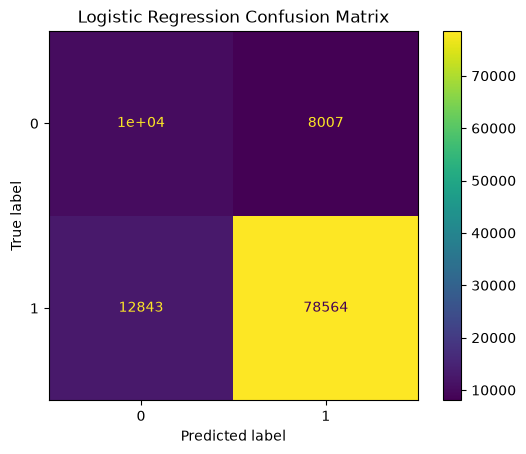

In [10]:
logistic_result = evaluate_model(
    model_name="Logistic Regression",
    model=logistic_model,
    X_test=X_test,
    y_test=y_test
)

logistic_result["train_time_sec"] = logistic_train_time

### Logistic Regression 계수 확인

In [11]:
logistic_coef = (
    logistic_model
    .named_steps["classifier"]
    .coef_[0]
)

coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": logistic_coef
}).sort_values(
    "coefficient",
    ascending=False
)

display(coef_df)

,feature,coefficient
0,recency_days,1.294279
7,n_purchase,0.927534
4,n_view,0.921153
6,n_remove_from_cart,0.910524
5,n_cart,0.901272
1,tenure_days,0.699154
9,purch_amt,0.048191
8,avg_price,-0.516528
2,ndays,-4.550141
3,n_events,-5.925166


### CatBoost 학습

In [12]:
catboost_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=100
)

start_time = time.time()

catboost_model.fit(
    X_fit,
    y_fit,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50,
    verbose=100
)

catboost_train_time = time.time() - start_time

print(
    f"CatBoost 학습 시간: "
    f"{catboost_train_time:.2f}초"
)

0:	test: 0.7855752	best: 0.7855752 (0)	total: 177ms	remaining: 1m 28s
100:	test: 0.8021210	best: 0.8021210 (100)	total: 2.19s	remaining: 8.64s
200:	test: 0.8028422	best: 0.8028558 (185)	total: 4.03s	remaining: 6s
300:	test: 0.8035056	best: 0.8035430 (287)	total: 6.07s	remaining: 4.01s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8035429932
bestIteration = 287

Shrink model to first 288 iterations.
CatBoost 학습 시간: 6.89초


### CatBoost 평가


[CatBoost]
              precision    recall  f1-score   support

           0     0.4192    0.6091    0.4967     18329
           1     0.9138    0.8308    0.8703     91407

    accuracy                         0.7938    109736
   macro avg     0.6665    0.7200    0.6835    109736
weighted avg     0.8312    0.7938    0.8079    109736



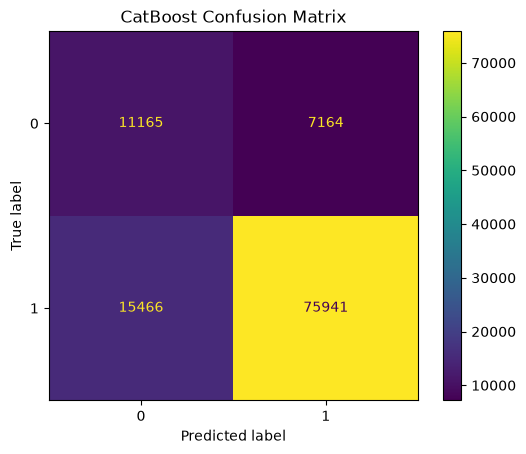

In [13]:
catboost_result = evaluate_model(
    model_name="CatBoost",
    model=catboost_model,
    X_test=X_test,
    y_test=y_test
)

catboost_result["train_time_sec"] = catboost_train_time

### CatBoost feature importance

In [14]:
catboost_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": catboost_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

display(catboost_importance)

,feature,importance
2,ndays,24.227198
0,recency_days,22.671024
1,tenure_days,18.623046
4,n_view,9.911072
3,n_events,8.683916
8,avg_price,4.824883
5,n_cart,3.478649
9,purch_amt,3.127186
6,n_remove_from_cart,2.741358
7,n_purchase,1.711668


### 두 모델 비교

In [15]:
results_df = pd.DataFrame([
    logistic_result,
    catboost_result
])

display(
    results_df.sort_values(
        "roc_auc",
        ascending=False
    )
)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,train_time_sec
1,CatBoost,0.793778,0.913796,0.830801,0.870324,0.789990,0.936037,6.894386
0,Logistic Regression,0.809999,0.907509,0.859497,0.882851,0.785966,0.934338,0.251926


### 모델 저장

In [16]:
joblib.dump(
    logistic_model,
    "logistic_regression_model.pkl"
)

catboost_model.save_model(
    "catboost_model.cbm"
)